In [113]:
from google.colab import files
uploaded=files.upload()

Saving liver.csv to liver (1).csv


In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [115]:
df=pd.read_csv("liver.csv",on_bad_lines='skip')

In [116]:
df

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,No Liver Disease
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,Liver Disease
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,Liver Disease
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,Liver Disease


In [117]:
df2 = df.copy()

df2.rename(columns=str.lower, inplace=True)



In [118]:

df2.head()

,age,gender,tb,db,alkphos,sgpt,sgot,tp,alb,a/g ratio,selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease


In [119]:
df2.rename(columns={'selector':'target'},inplace=True)

In [120]:
df2

,age,gender,tb,db,alkphos,sgpt,sgot,tp,alb,a/g ratio,target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,No Liver Disease
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,Liver Disease
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,Liver Disease
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,Liver Disease


In [121]:
df.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.946947
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.318495
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000


In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        583 non-null    int64  
 1   Gender     583 non-null    object 
 2   TB         583 non-null    float64
 3   DB         583 non-null    float64
 4   Alkphos    583 non-null    int64  
 5   Sgpt       583 non-null    int64  
 6   Sgot       583 non-null    int64  
 7   TP         583 non-null    float64
 8   ALB        583 non-null    float64
 9   A/G Ratio  583 non-null    float64
 10  Selector   583 non-null    object 
dtypes: float64(5), int64(4), object(2)
memory usage: 50.2+ KB


In [123]:
df.isna().sum()

,0
Age,0
Gender,0
TB,0
DB,0
Alkphos,0
Sgpt,0
Sgot,0
TP,0
ALB,0
A/G Ratio,0


In [124]:
df.duplicated().sum()

np.int64(13)

In [125]:

from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse_output=False)
df2['gender'] = encoder.fit_transform(df2[['gender']]).astype(int)
df2['target'] = encoder.fit_transform(df2[['target']]).astype(int)




In [126]:
pd.DataFrame(df2.corr().drop(labels='gender', axis=0)['target'].sort_values(ascending=False))

,target
target,1.000000
a/g ratio,0.162144
alb,0.161388
tp,0.035008
age,-0.137351
sgot,-0.151934
sgpt,-0.163416
alkphos,-0.184866
tb,-0.220208
db,-0.246046


### Correlation with Target

- a/g_ratio and albumin show weak positive correlation with target.
- Total protein has very low correlation.
- Age and gender have slight negative correlation.
- Liver enzymes (sgpt, sgot, alkphos) show weak negative correlation.
- Bilirubin levels (tb, db) have the highest negative correlation.

**Conclusion:** No feature has strong correlation -> model needs combination of features.

In [127]:
df2

,age,gender,tb,db,alkphos,sgpt,sgot,tp,alb,a/g ratio,target
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,0
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,0
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,0
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,0
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,0
...,...,...,...,...,...,...,...,...,...,...,...
578,60,1,0.5,0.1,500,20,34,5.9,1.6,0.37,1
579,40,1,0.6,0.1,98,35,31,6.0,3.2,1.10,0
580,52,1,0.8,0.2,245,48,49,6.4,3.2,1.00,0
581,31,1,1.3,0.5,184,29,32,6.8,3.4,1.00,0


([<matplotlib.patches.Wedge at 0x79a315ce3ad0>,
 [Text(-0.746019130671921, 0.9399231121062569, 'Liver disease'),
  Text(0.683850739685182, -0.8615962893560009, '  No Liver disease')],
 [Text(-0.4351778262252873, 0.5482884820619831, '71.4%'),
  Text(0.37300949437373554, -0.4699616123760004, '28.6%')])

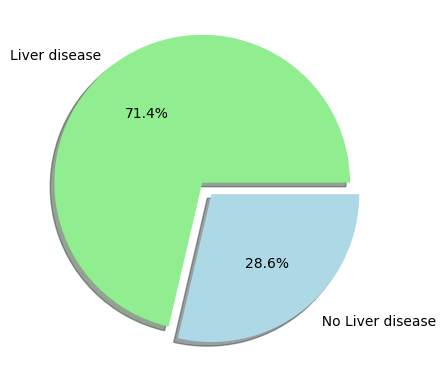

In [128]:
plt.pie(x=df2['target'].value_counts(),autopct="%1.1f%%",labels=['Liver disease','  No Liver disease'],colors=['lightgreen','lightblue'],explode=[0.1,0],shadow=True)



> # Data is not that much bad in distribution



In [129]:
df.groupby('Gender')['Selector'].value_counts(normalize=True)

Gender  Selector        
Female  Liver Disease       0.647887
        No Liver Disease    0.352113
Male    Liver Disease       0.734694
        No Liver Disease    0.265306
Name: proportion, dtype: float64

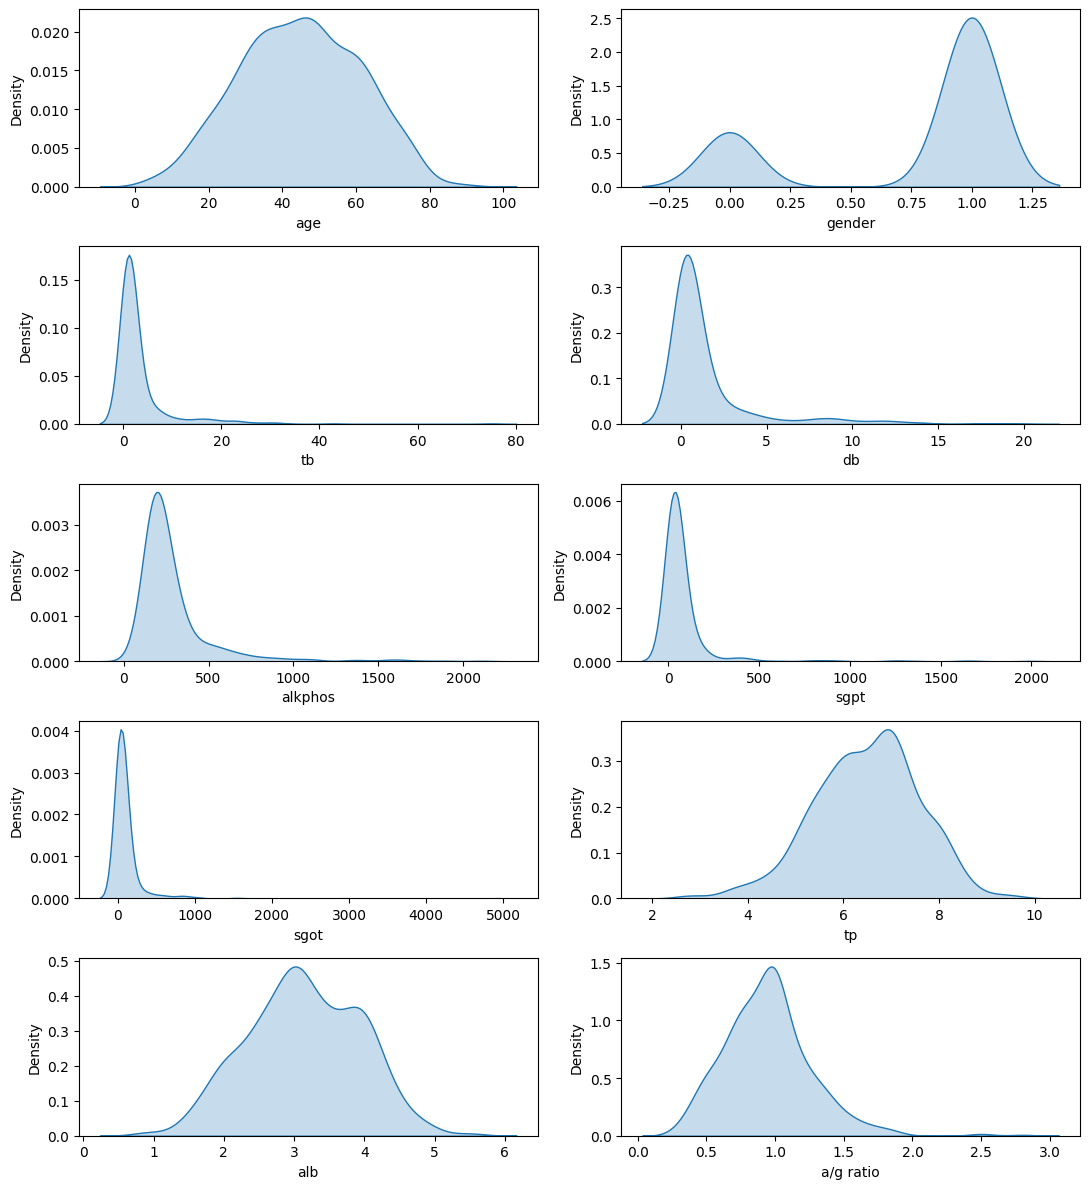

In [130]:
nums_col=['age', 'gender', 'tb', 'db', 'alkphos', 'sgpt', 'sgot', 'tp', 'alb',
       'a/g ratio']
fig,axes=plt.subplots(5,2,figsize=(11,12))
axes=axes.flatten()
for i,col in enumerate(nums_col):
  sns.kdeplot(data=df2,x=col,fill=True,ax=axes[i])
plt.tight_layout()
plt.show()

##  EDA Summary (KDE Plots)

- **Age**: Approximately normal distribution → no major preprocessing needed  
- **Gender**: Binary categorical variable → treat as category  

- **tb, db**: Right-skewed with outliers
- **alkphos, sgpt, sgot**: Highly right-skewed  

- **tp**: Near normal distribution -acceptable  
- **alb**: Slight skew - minor scaling  
- **A/G Ratio**: Slight right skew - optional scaling  

### Key Points
- Most medical features are **positively skewed**
- **Outliers present** (clinically important)
- Preprocessing required for skewed features

### Conclusion
Data requires **scaling and transformation** before model training.

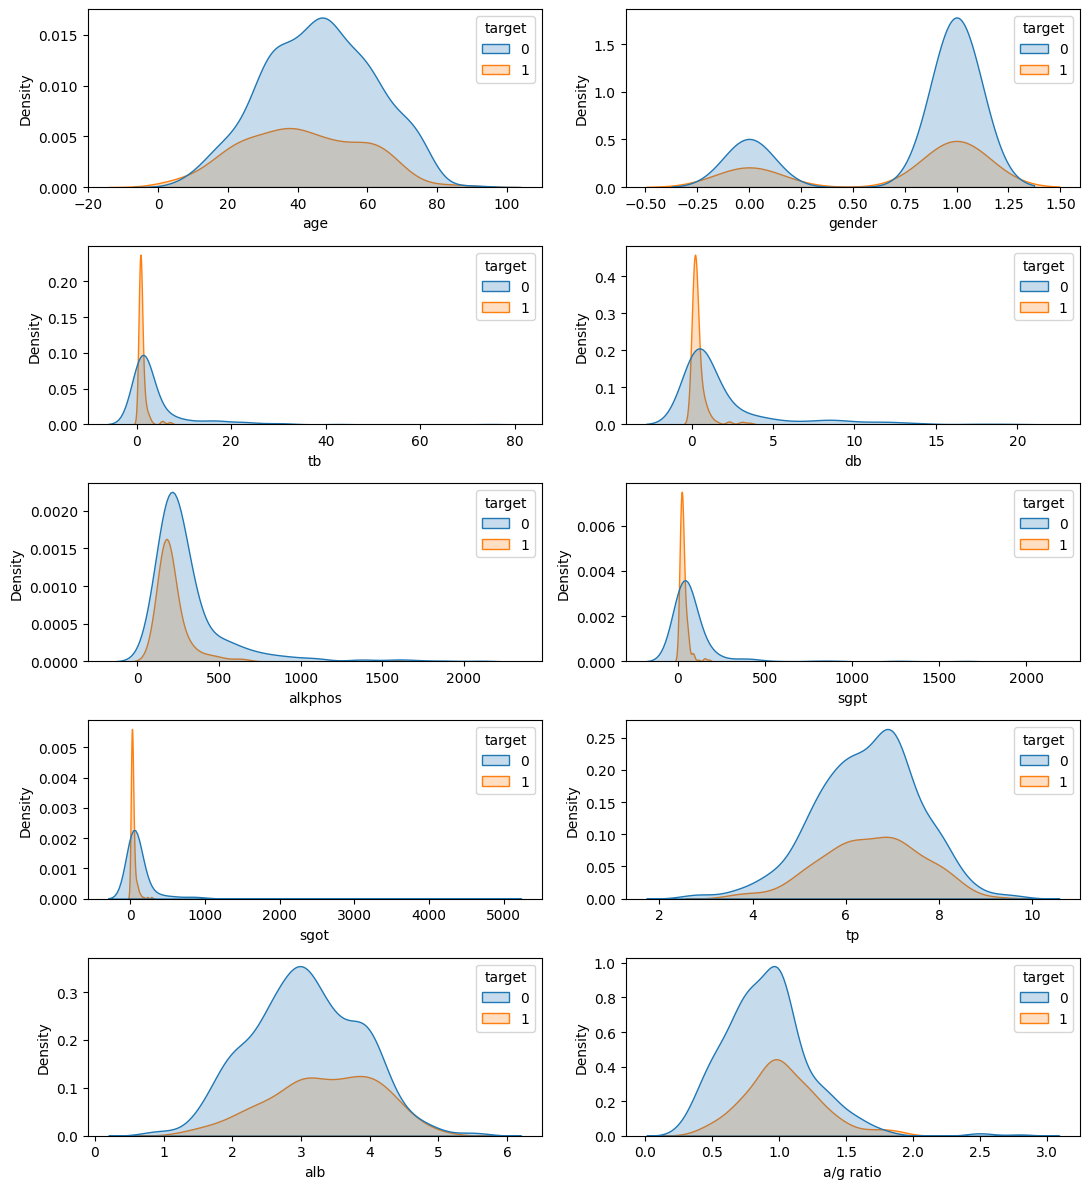

In [131]:
nums_col=['age', 'gender', 'tb', 'db', 'alkphos', 'sgpt', 'sgot', 'tp', 'alb',
       'a/g ratio']
fig,axes=plt.subplots(5,2,figsize=(11,12))
axes=axes.flatten()
for i,col in enumerate(nums_col):
  sns.kdeplot(data=df2,x=col,fill=True,ax=axes[i],hue='target')
plt.tight_layout()
plt.show()

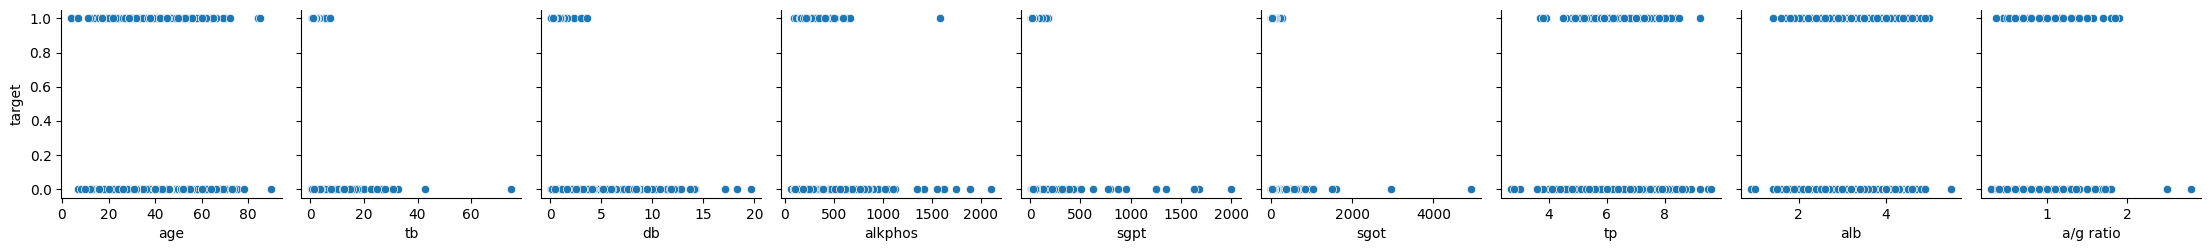

In [132]:
sns.pairplot(df2,x_vars=df2.drop(columns=['target','gender'],axis=1),y_vars='target')

# More insights:
- Tb->liver disease almost b/w 0-15
- Db->0-5
- sgpt->aprrox 0-400
- sgot->approx 0-500
- tp-> greater than 4 liver disease

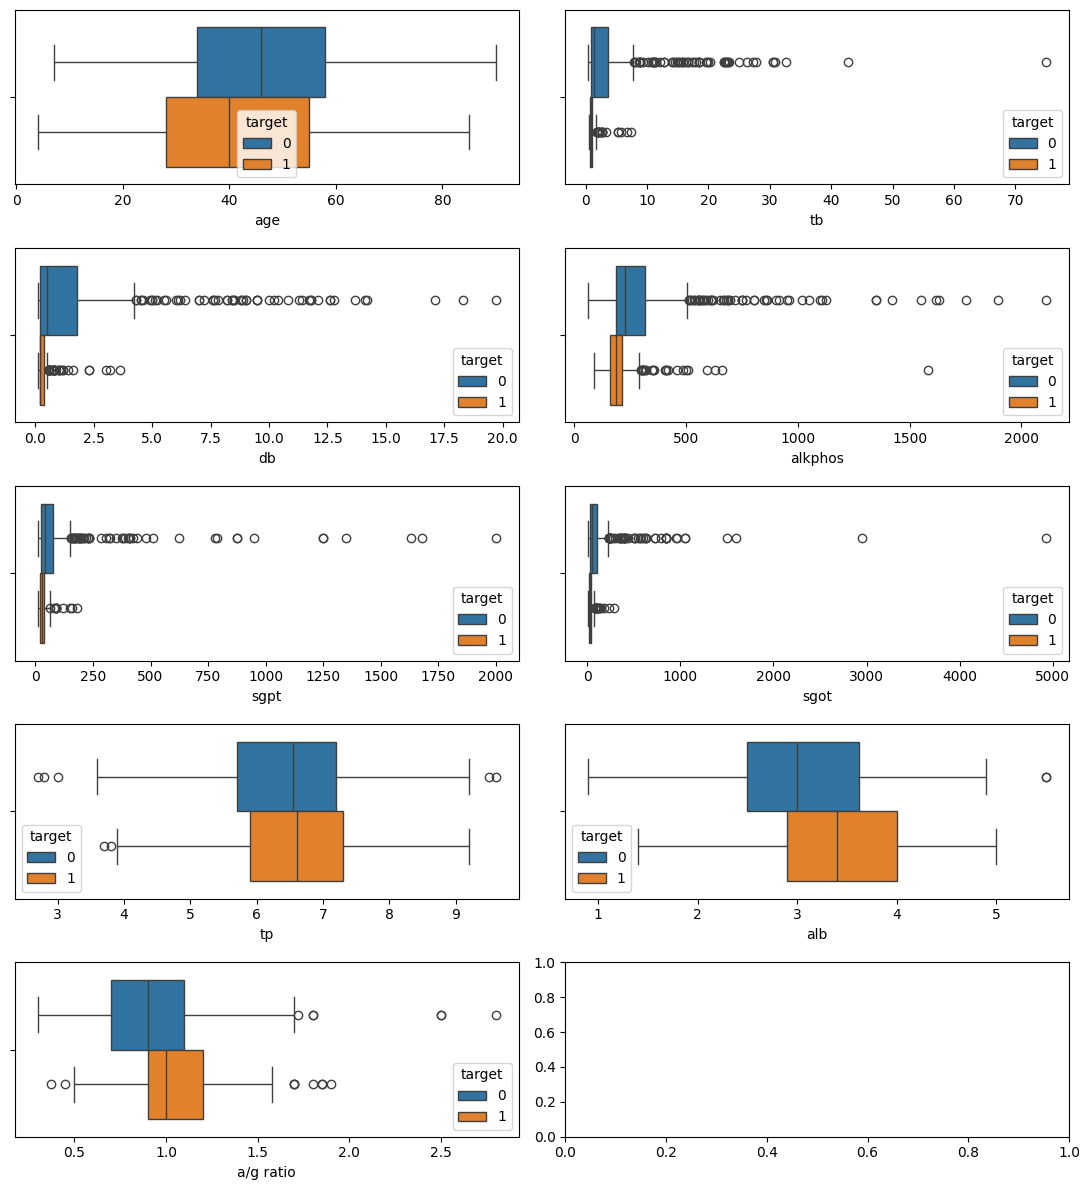

In [133]:
nums_col=['age', 'tb', 'db', 'alkphos', 'sgpt', 'sgot', 'tp', 'alb',
       'a/g ratio']
fig,axes=plt.subplots(5,2,figsize=(11,12))
axes=axes.flatten()
for i,col in enumerate(nums_col):
  sns.boxplot(data=df2,x=col,fill=True,ax=axes[i],hue='target')
plt.tight_layout()
plt.show()

# Box plot interpretation
#### **Age: No such  outliers**


#### **tb, db,alkphos, sgpt, sgot:  Outliers present**


#### **A/G Ratio: Slight outliers**


#

<Axes: xlabel='Gender', ylabel='count'>

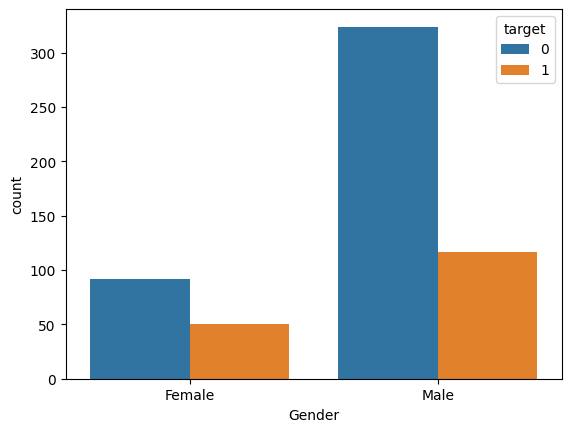

In [134]:
sns.countplot(x=df['Gender'],hue=df2['target'])

In [135]:
df['Selector']=df['Selector'].map({'Liver Disease':1,'No Liver Disease':0})

<Axes: >

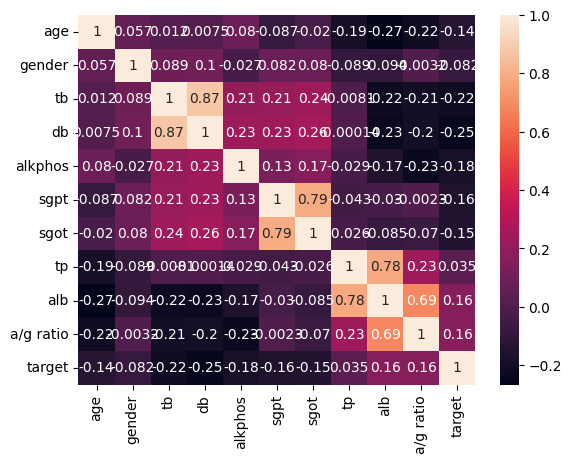

In [136]:
sns.heatmap(df2.corr(),annot=True)

In [137]:
table=pd.crosstab(df['Gender'],df['Selector'])

In [138]:
table

Selector,0,1
Gender,,
Female,50,92
Male,117,324


In [139]:
from scipy.stats import chi2_contingency

In [140]:
chi2, p, dof, expected = chi2_contingency(table)

In [141]:
print("Chi-square:", chi2)
print("P-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", expected)

Chi-square: 3.5466486106706046
P-value: 0.059665846857774464
Degrees of freedom: 1
Expected frequencies:
 [[ 40.67581475 101.32418525]
 [126.32418525 314.67581475]]


In [142]:
if p < 0.05:
    print("Reject Null Hypothesis")
    print("Association exists")
else:
    print("Fail to Reject Null")
    print("No association")

Fail to Reject Null
No association


# Null Hypothesis:**Relationship b/w the gender and  the target column**
# Alternative Hypothesis: **Their is a relationship b/w them**

## Since, the p-value is greater than 0.05, we fail to reject the null hypothesis. Hence, no significant association exists between the variables.

"More males have liver disease (73.5%) compared to females (64.7%), but this difference is not statistically significant (p=0.059). We are keeping the gender column because the result is very close to the significance threshold and gender is a known risk factor in liver disease."

In [143]:
df.columns=df.columns.str.lower()

In [144]:
df=df.rename(columns={'selector':'target'})

In [145]:
df

,age,gender,tb,db,alkphos,sgpt,sgot,tp,alb,a/g ratio,target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,0
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [146]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix,f1_score,recall_score,precision_score


In [147]:
x=df.drop(columns=['target'],axis=1)
y=df['target']

In [148]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y,shuffle=True)

In [149]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(466, 10)
(117, 10)
(466,)
(117,)


In [150]:
col_trans=ColumnTransformer(transformers=[('ohe',OneHotEncoder(drop='first',sparse_output=False),['gender'])],remainder='passthrough')

In [151]:
pipe_xg=Pipeline(
    [

    ('col_trans',col_trans),
    ('model',XGBClassifier())
    ]

)

In [152]:
params_grid_xg = [
    {
        'model__n_estimators': range(100, 500, 20),
        'model__max_depth': range(3, 15),
        'model__learning_rate': np.linspace(0.01, 0.3, 30),

        'model__subsample': np.linspace(0.5, 1, 6),
        'model__reg_lambda': np.linspace(0.01, 1, 20),
        'model__colsample_bytree': np.linspace(0.5, 1, 6)
    }
]

In [153]:
grid_xgboost= RandomizedSearchCV(
    estimator=pipe_xg,
    param_distributions=params_grid_xg,
    cv=5,
    n_jobs=-1,
    scoring='f1_macro'
)

In [154]:
best_estimator_xgboost=grid_xgboost.fit(x_train,y_train)

In [155]:
print(best_estimator_xgboost.best_params_)
print(best_estimator_xgboost.best_score_)

{'model__subsample': np.float64(1.0), 'model__reg_lambda': np.float64(0.16631578947368422), 'model__n_estimators': 180, 'model__max_depth': 10, 'model__learning_rate': np.float64(0.20999999999999996), 'model__colsample_bytree': np.float64(0.7)}
0.6197220197362844


In [156]:
y_pred_xg=best_estimator_xgboost.predict(x_test)

In [157]:
print(classification_report(y_test, y_pred_xg))

              precision    recall  f1-score   support

           0       0.55      0.32      0.41        34
           1       0.76      0.89      0.82        83

    accuracy                           0.73       117
   macro avg       0.66      0.61      0.61       117
weighted avg       0.70      0.73      0.70       117



In [158]:
print(confusion_matrix(y_test, y_pred_xg))
print("AUC-ROC:  ", roc_auc_score(y_test, y_pred_xg))

[[11 23]
 [ 9 74]]
AUC-ROC:   0.6075478384124734


## XGBoost Model Analysis

The tuned XGBoost model achieved a macro average F1-score of 0.63.

The model performs significantly better on class 1 compared to class 0.

### Class-wise Performance

- Class 1:
  - Precision: 0.77
  - Recall: 0.92
  - F1-score: 0.84

- Class 0:
  - Precision: 0.61
  - Recall: 0.32
  - F1-score: 0.42

The high recall for class 1 indicates that the model successfully identifies most samples belonging to class 1.

However, recall for class 0 is relatively low, meaning many class 0 samples are incorrectly classified as class 1.

### Imbalance Effect

The dataset contains class imbalance:

- Class 1: 416 samples
- Class 0: 167 samples

Due to the higher number of class 1 samples, the model tends to learn patterns of the majority class more effectively.

helped improve class balance and reduced excessive bias toward the majority class.

### Conclusion

The model demonstrates good predictive performance for the majority class but still struggles with minority class detection.

Although overall performance improved after tuning, further techniques such as imbalance handling (e.g., SMOTE) may help improve recall and F1-score for class 0.

# Now Using SMOTE may be it will help


In [159]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [160]:
col_trans=ColumnTransformer(transformers=[('ohe',OneHotEncoder(drop='first',sparse_output=False),['gender'])],remainder='passthrough')
pipe_xg_sm=ImbPipeline(
    [

    ('col_trans',col_trans),
    ('smote',SMOTE(random_state=42,sampling_strategy=0.5)),
    ('model',XGBClassifier())
    ]

)

In [161]:
grid_xgboost_sm= RandomizedSearchCV(
    estimator=pipe_xg_sm,
    param_distributions=params_grid_xg,
    cv=5,
    n_jobs=-1,
    scoring='f1_macro',
      error_score='raise'
)

In [162]:
best_estimator_xg_sm=grid_xgboost_sm.fit(x_train,y_train)

In [163]:
print(best_estimator_xg_sm.best_params_)
print(best_estimator_xg_sm.best_score_)

{'model__subsample': np.float64(0.7), 'model__reg_lambda': np.float64(0.791578947368421), 'model__n_estimators': 480, 'model__max_depth': 12, 'model__learning_rate': np.float64(0.06999999999999999), 'model__colsample_bytree': np.float64(0.5)}
0.6224933018256333


In [164]:
y_pred_xg_sm=best_estimator_xg_sm.predict(x_test)

In [165]:
print(confusion_matrix(y_test, y_pred_xg_sm))
print("AUC-ROC:  ", roc_auc_score(y_test, y_pred_xg_sm))
print(classification_report(y_test, y_pred_xg_sm))

[[11 23]
 [ 7 76]]
AUC-ROC:   0.6195960311835578
              precision    recall  f1-score   support

           0       0.61      0.32      0.42        34
           1       0.77      0.92      0.84        83

    accuracy                           0.74       117
   macro avg       0.69      0.62      0.63       117
weighted avg       0.72      0.74      0.72       117



After applying SMOTE, the XGBoost model showed improved performance on the minority class.

The recall for class 0 increased from 0.32 to 0.38, while the F1-score improved from 0.42 to 0.49. The macro average F1-score also improved, indicating better balanced performance across both classes.

Additionally, the ROC-AUC score increased from 0.62 to 0.66, suggesting improved class discrimination capability.

These improvements indicate that SMOTE helped reduce the impact of class imbalance by generating synthetic minority-class samples, allowing the model to learn minority patterns more effectively.